# multi-task fc 实验可视化

处理 `record/4-LIF_fc/`、`record/5-LIF_fc/`、`record/5-LIF_fc-dropout/` 下的日志：
- 柱状图：每种拓扑最后一个 epoch 的 acc1, acc2，按 seed 求平均（三组各一张，每张 2 子图）
- 折线图：每种拓扑每 epoch 的 loss，按 seed 求平均（无误差线）

In [4]:
import os
import re
import json
from collections import defaultdict
import numpy as np
import matplotlib.pyplot as plt

RECORD_DIR = os.path.join(os.path.dirname(os.path.abspath('__file__') if '__file__' in dir() else '.'), 'record')
GROUPS = ['4-LIF_fc', '5-LIF_fc', '5-LIF_fc-dropout']

EPOCH_RE = re.compile(r'Epoch:\s*(\d+)\s+Loss:\s*([-\d.]+)\s+acc1:\s*([-\d.]+)\s+acc2:\s*([-\d.]+)')
LOG_NAME_RE = re.compile(r'^(?P<model>.+?)_seed(?P<seed>\d+)\.log$')

In [5]:
def parse_log(path):
    rows = []
    with open(path, 'r') as f:
        for line in f:
            m = EPOCH_RE.search(line)
            if m:
                rows.append((int(m.group(1)), float(m.group(2)),
                             float(m.group(3)), float(m.group(4))))
    return rows


def load_group(group):
    group_dir = os.path.join(RECORD_DIR, group)
    data = defaultdict(dict)  # model -> seed -> rows
    for fname in sorted(os.listdir(group_dir)):
        m = LOG_NAME_RE.match(fname)
        if not m:
            continue
        model = m.group('model')
        seed = int(m.group('seed'))
        data[model][seed] = parse_log(os.path.join(group_dir, fname))
    return data

In [6]:
data = {group: load_group(group) for group in GROUPS}
for group in GROUPS:
    print(f'{group}: {len(data[group])} models')
    for m, seeds in data[group].items():
        n_seeds = len(seeds)
        n_epochs = len(next(iter(seeds.values())))
        print(f'  {m}: {n_seeds} seeds, {n_epochs} epochs')

4-LIF_fc: 6 models
  4LIF_fc: 3 seeds, 40 epochs
  LIF_1_1_1_1: 3 seeds, 40 epochs
  LIF_1_2_1: 3 seeds, 40 epochs
  LIF_1_3: 3 seeds, 40 epochs
  LIF_2_2: 3 seeds, 40 epochs
  LIF_hh_fc: 3 seeds, 40 epochs
5-LIF_fc: 6 models
  LIF_1_1_1_1_1: 3 seeds, 40 epochs
  LIF_1_1_2_1: 3 seeds, 40 epochs
  LIF_1_1_3: 3 seeds, 40 epochs
  LIF_1_2_2: 3 seeds, 40 epochs
  LIF_1_3_1: 3 seeds, 40 epochs
  LIF_1_4: 3 seeds, 40 epochs
5-LIF_fc-dropout: 6 models
  LIF_1_1_1_1_1: 3 seeds, 40 epochs
  LIF_1_1_2_1: 3 seeds, 40 epochs
  LIF_1_1_3: 3 seeds, 40 epochs
  LIF_1_2_2: 3 seeds, 40 epochs
  LIF_1_3_1: 3 seeds, 40 epochs
  LIF_1_4: 3 seeds, 40 epochs


## 柱状图：最后一个 epoch 的 acc1 / acc2（按 seed 平均）

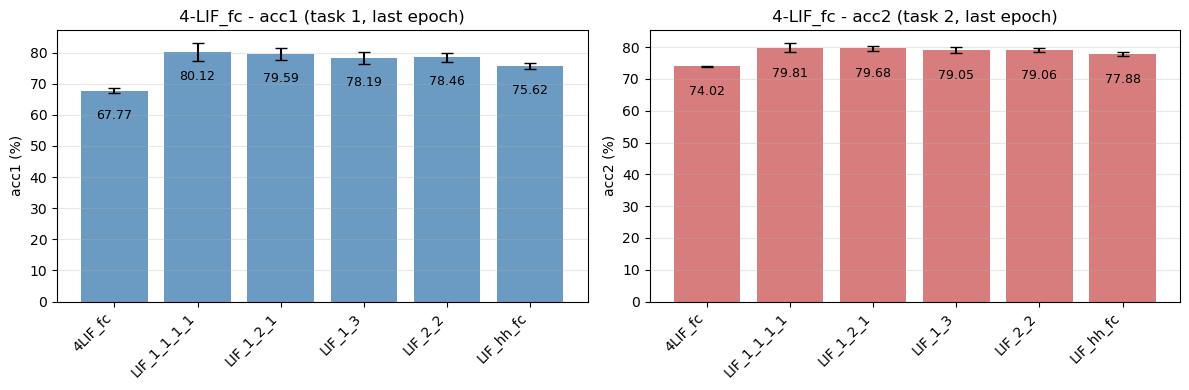

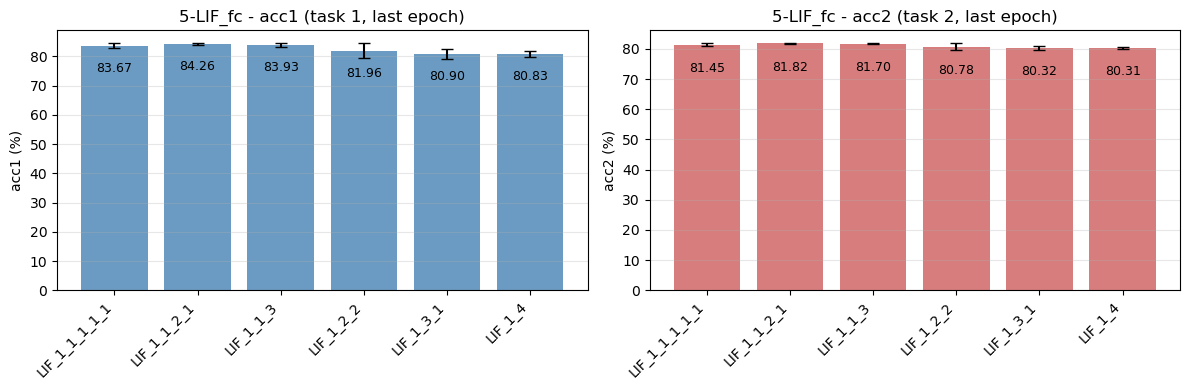

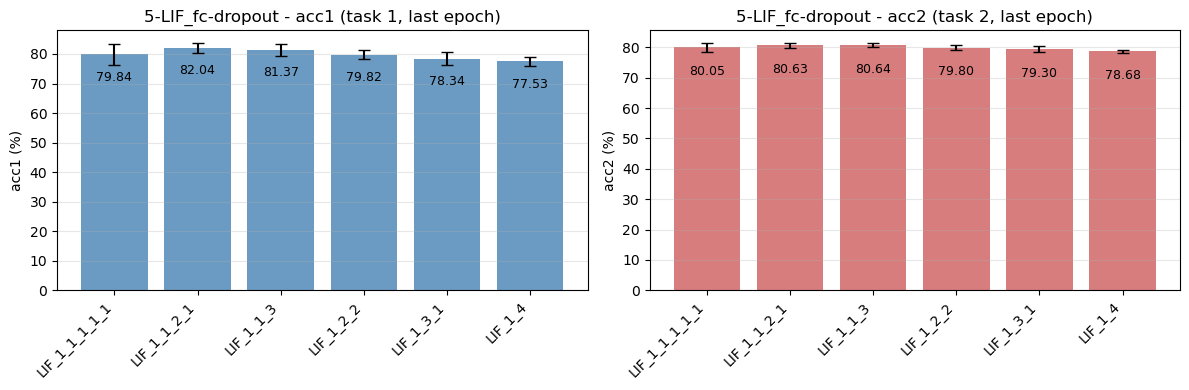

In [7]:
def last_epoch_accs(model_seeds):
    acc1, acc2 = [], []
    for rows in model_seeds.values():
        if rows:
            _, _, a1, a2 = rows[-1]
            acc1.append(a1); acc2.append(a2)
    return np.mean(acc1), np.mean(acc2), np.std(acc1), np.std(acc2)

for group in GROUPS:
    models = sorted(data[group].keys())
    acc1_means, acc2_means, acc1_stds, acc2_stds = [], [], [], []
    for m in models:
        a1, a2, s1, s2 = last_epoch_accs(data[group][m])
        acc1_means.append(a1); acc2_means.append(a2)
        acc1_stds.append(s1); acc2_stds.append(s2)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    x = np.arange(len(models))

    # 左图 acc1
    axes[0].bar(x, acc1_means, yerr=acc1_stds, capsize=4, color='steelblue', alpha=0.8)
    axes[0].set_xticks(x); axes[0].set_xticklabels(models, rotation=45, ha='right')
    axes[0].set_ylabel('acc1 (%)')
    axes[0].set_title(f'{group} - acc1 (task 1, last epoch)')
    axes[0].grid(axis='y', alpha=0.3)

    # 在每根柱子顶部标均值
    for i, m in enumerate(acc1_means):
        axes[0].text(i, m - 10, f'{m:.2f}', ha='center', va='bottom', fontsize=9)

    # 右图 acc2（同样处理）
    axes[1].bar(x, acc2_means, yerr=acc2_stds, capsize=4, color='indianred', alpha=0.8)
    axes[1].set_xticks(x); axes[1].set_xticklabels(models, rotation=45, ha='right')
    axes[1].set_ylabel('acc2 (%)')
    axes[1].set_title(f'{group} - acc2 (task 2, last epoch)')
    axes[1].grid(axis='y', alpha=0.3)

    for i, m in enumerate(acc2_means):
        axes[1].text(i, m - 10, f'{m:.2f}', ha='center', va='bottom', fontsize=9)

    fig.tight_layout()
    plt.show()

## 折线图：每 epoch loss（按 seed 平均，无误差线）

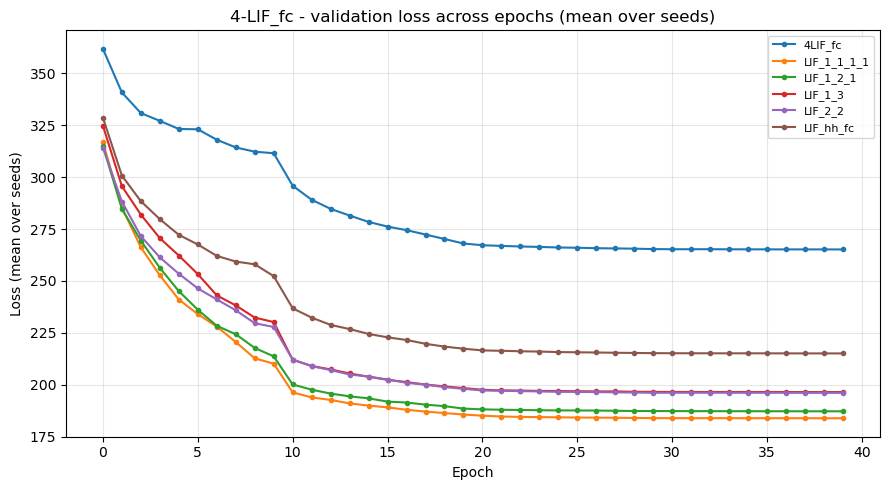

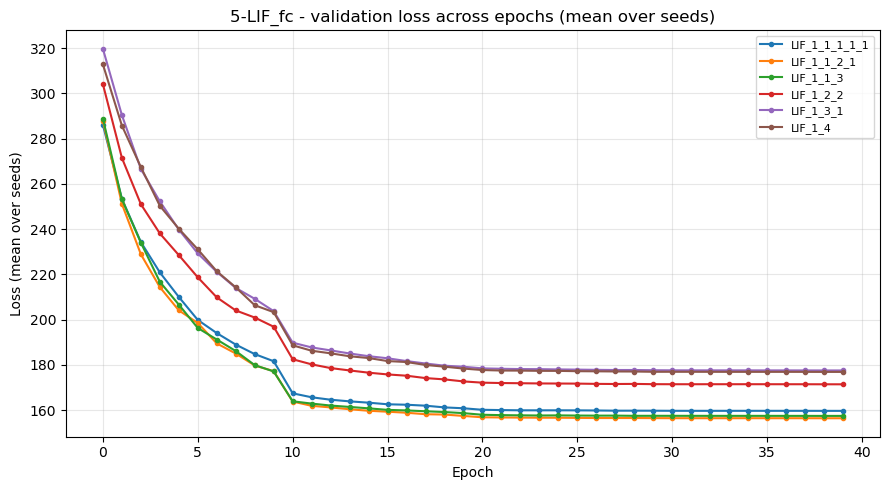

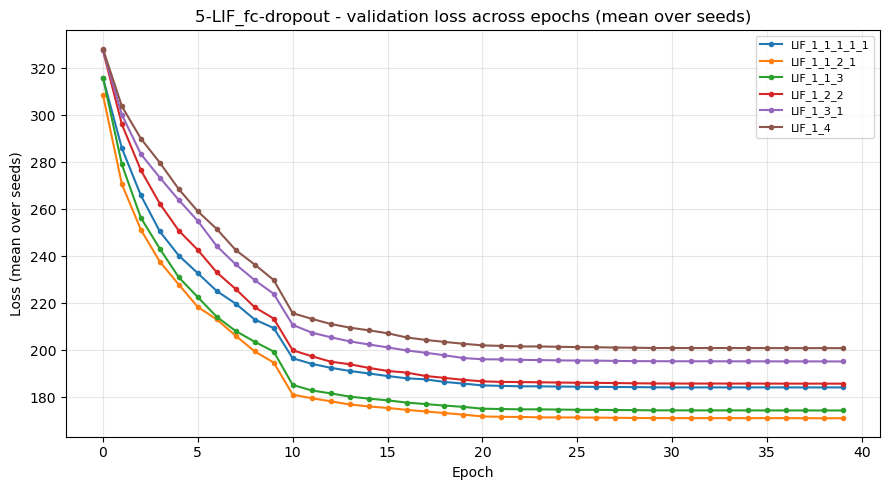

In [8]:
def per_epoch_loss_mean(model_seeds):
    """Return (epochs, mean_loss_per_epoch) averaged across seeds."""
    epoch_to_losses = defaultdict(list)
    for rows in model_seeds.values():
        for ep, loss, _, _ in rows:
            epoch_to_losses[ep].append(loss)
    epochs = sorted(epoch_to_losses)
    means = [np.mean(epoch_to_losses[e]) for e in epochs]
    return np.array(epochs), np.array(means)

for group in GROUPS:
    fig, ax = plt.subplots(figsize=(9, 5))
    for m in sorted(data[group].keys()):
        epochs, means = per_epoch_loss_mean(data[group][m])
        ax.plot(epochs, means, marker='o', markersize=3, label=m)
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss (mean over seeds)')
    ax.set_title(f'{group} - validation loss across epochs (mean over seeds)')
    ax.legend(loc='best', fontsize=8); ax.grid(alpha=0.3)
    fig.tight_layout(); plt.show()